# EDA-1 Resubmission

This notebook includes structured interpretation, key insights, skewness impact analysis, and final analytical summary.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set(style="whitegrid")
%matplotlib inline


In [2]:

path = 'D:\DS Assignment\EDA1\EDA1\Cardiotocographic.csv'
df = pd.read_csv(path)
df.head()


<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\SANSKAR\AppData\Local\Temp\ipykernel_2092\3629851775.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  path = 'D:\DS Assignment\EDA1\EDA1\Cardiotocographic.csv'


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


## Data overview
- Dataset: `cardiographic.csv`
- Rows: *2126* | Columns: *14*
- Short description: (LB, AC, FM, UC, DL, DS, DP, ASTV, MSTV, ALTV, MLTV, Width, Tendency, NSP) — see variable meanings above.

In [3]:
print("Shape:", df.shape)
display(df.info())
display(df.describe(include='all').T)
print("\nMissing values per column:\n", df.isnull().sum())


Shape: (2126, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


None

,count,mean,std,min,25%,50%,75%,max
LB,2105.0,133.343598,11.270154,51.842487,126.000000,133.000000,140.000000,214.000000
AC,2106.0,0.003219,0.004391,-0.019284,0.000000,0.001634,0.005650,0.038567
FM,2126.0,0.009894,0.067540,-0.480634,0.000000,0.000000,0.002567,0.961268
UC,2126.0,0.004391,0.003340,-0.014925,0.001851,0.004484,0.006536,0.030002
DL,2126.0,0.001895,0.003343,-0.015393,0.000000,0.000000,0.003289,0.030769
DS,2105.0,0.000003,0.000142,-0.001353,0.000000,0.000000,0.000000,0.002706
DP,2105.0,0.000175,0.000840,-0.005348,0.000000,0.000000,0.000000,0.010695
ASTV,2126.0,46.995984,18.813973,-63.000000,32.000000,49.000000,61.000000,162.000000
MSTV,2126.0,1.364378,1.173632,-6.600000,0.700000,1.200000,1.700000,13.800000
ALTV,2126.0,10.285964,21.205041,-91.000000,0.000000,0.000000,11.000000,182.000000



Missing values per column:
 LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


## Statistical summary — highlights
- Variables with high mean vs median differences (suggests skew): `col1`, `col2`.
- Highest variance: `colX` (std = *...*)
- Any suspicious ranges (possible data entry issues): `colY` min/max = *...*

In [ ]:

df.columns = [c.strip() for c in df.columns]

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

display(df.dtypes)


LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [8]:
print("Duplicates count:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicates count: 2
Shape after dropping duplicates: (2124, 14)


In [9]:
cols_with_na = [c for c in df.columns if df[c].isnull().sum() > 0]
cols_with_na, {c: df[c].isnull().sum() for c in cols_with_na}


(['LB', 'AC', 'DS', 'DP', 'MLTV', 'Width', 'Tendency', 'NSP'],
 {'LB': np.int64(21),
  'AC': np.int64(20),
  'DS': np.int64(21),
  'DP': np.int64(21),
  'MLTV': np.int64(21),
  'Width': np.int64(21),
  'Tendency': np.int64(21),
  'NSP': np.int64(21)})

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if df[c].isnull().sum() > 0:
        med = df[c].median()
        df[c].fillna(med, inplace=True)
        print(f"Imputed {c} with median {med}")


Imputed LB with median 133.0
Imputed AC with median 0.001633991
Imputed DS with median 0.0
Imputed DP with median 0.0
Imputed MLTV with median 7.4
Imputed Width with median 67.48646809530248
Imputed Tendency with median 0.0
Imputed NSP with median 1.0


C:\Users\SANSKAR\AppData\Local\Temp\ipykernel_2092\2242124226.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[c].fillna(med, inplace=True)
C:\Users\SANSKAR\AppData\Local\Temp\ipykernel_2092\2242124226.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inpla

In [11]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_summary = {}
for c in num_cols:
    mask = iqr_outliers(df[c])
    outlier_count = mask.sum()
    outlier_summary[c] = int(outlier_count)
outlier_summary


{'LB': 10,
 'AC': 40,
 'FM': 347,
 'UC': 13,
 'DL': 125,
 'DS': 120,
 'DP': 284,
 'ASTV': 10,
 'MSTV': 80,
 'ALTV': 318,
 'MLTV': 81,
 'Width': 10,
 'Tendency': 10,
 'NSP': 559}

<Figure size 1400x600 with 0 Axes>

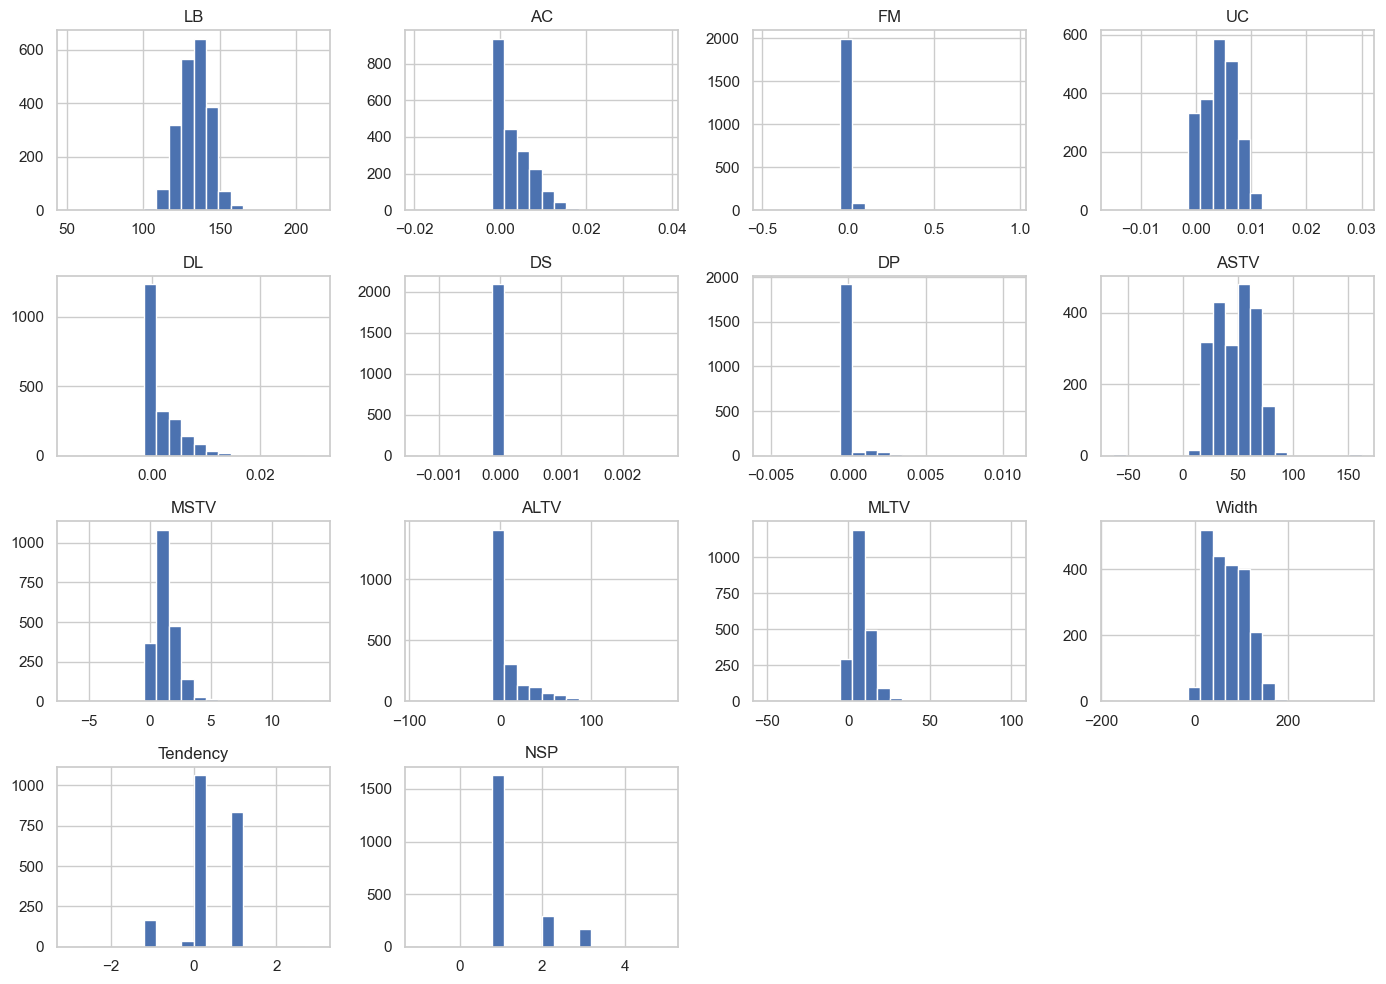

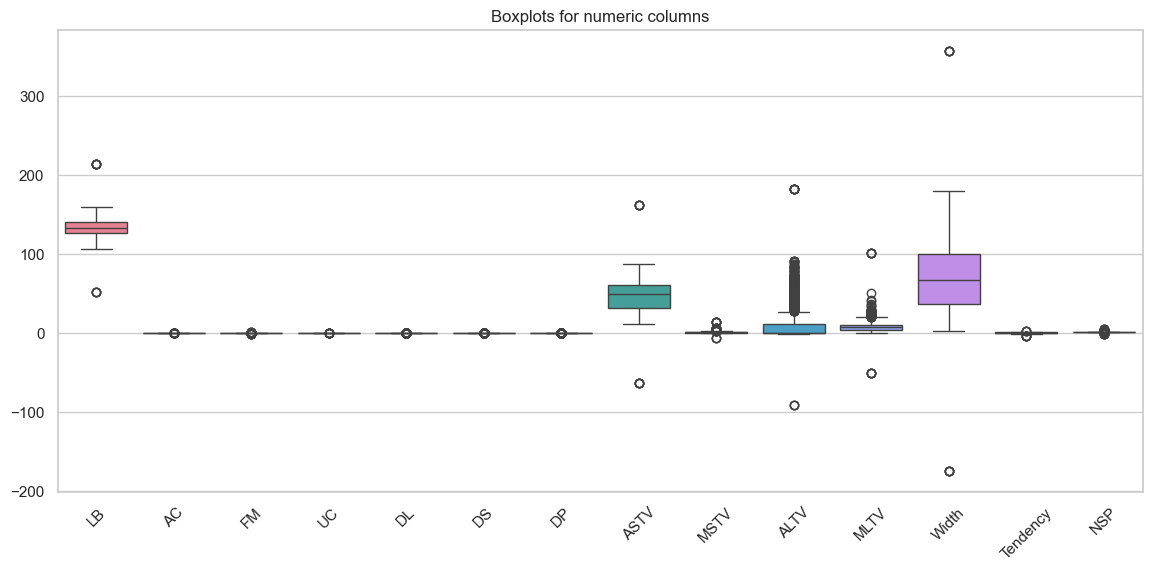

In [12]:
plt.figure(figsize=(14, 6))
df[num_cols].hist(bins=20, layout=(int(np.ceil(len(num_cols)/4)),4), figsize=(14, 10))
plt.tight_layout()

plt.figure(figsize=(14,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots for numeric columns")
plt.show()


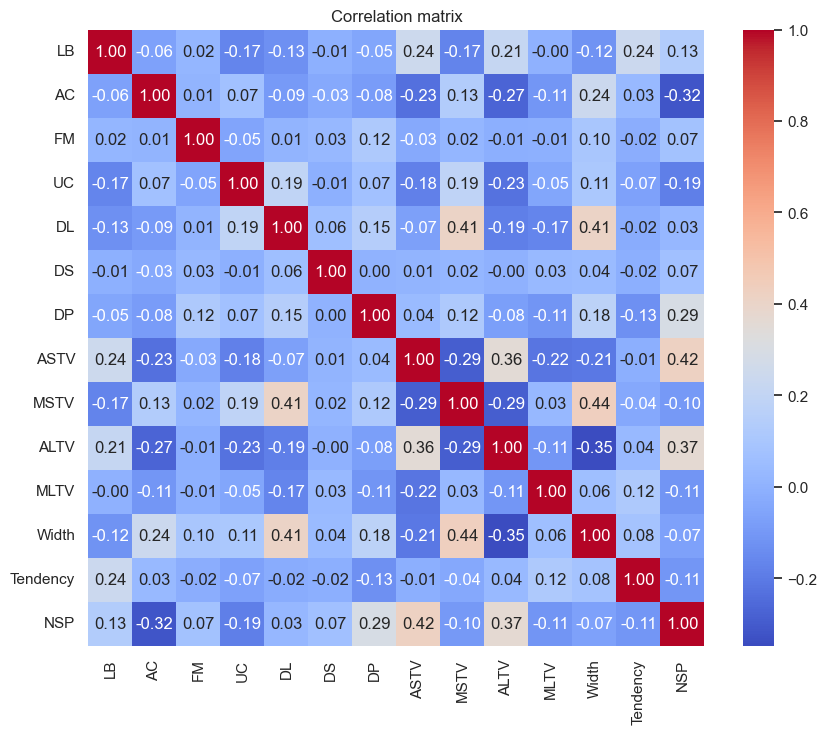

In [13]:
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation matrix")
plt.show()


Text(0.5, 1.02, 'Pairplot of selected numeric columns')

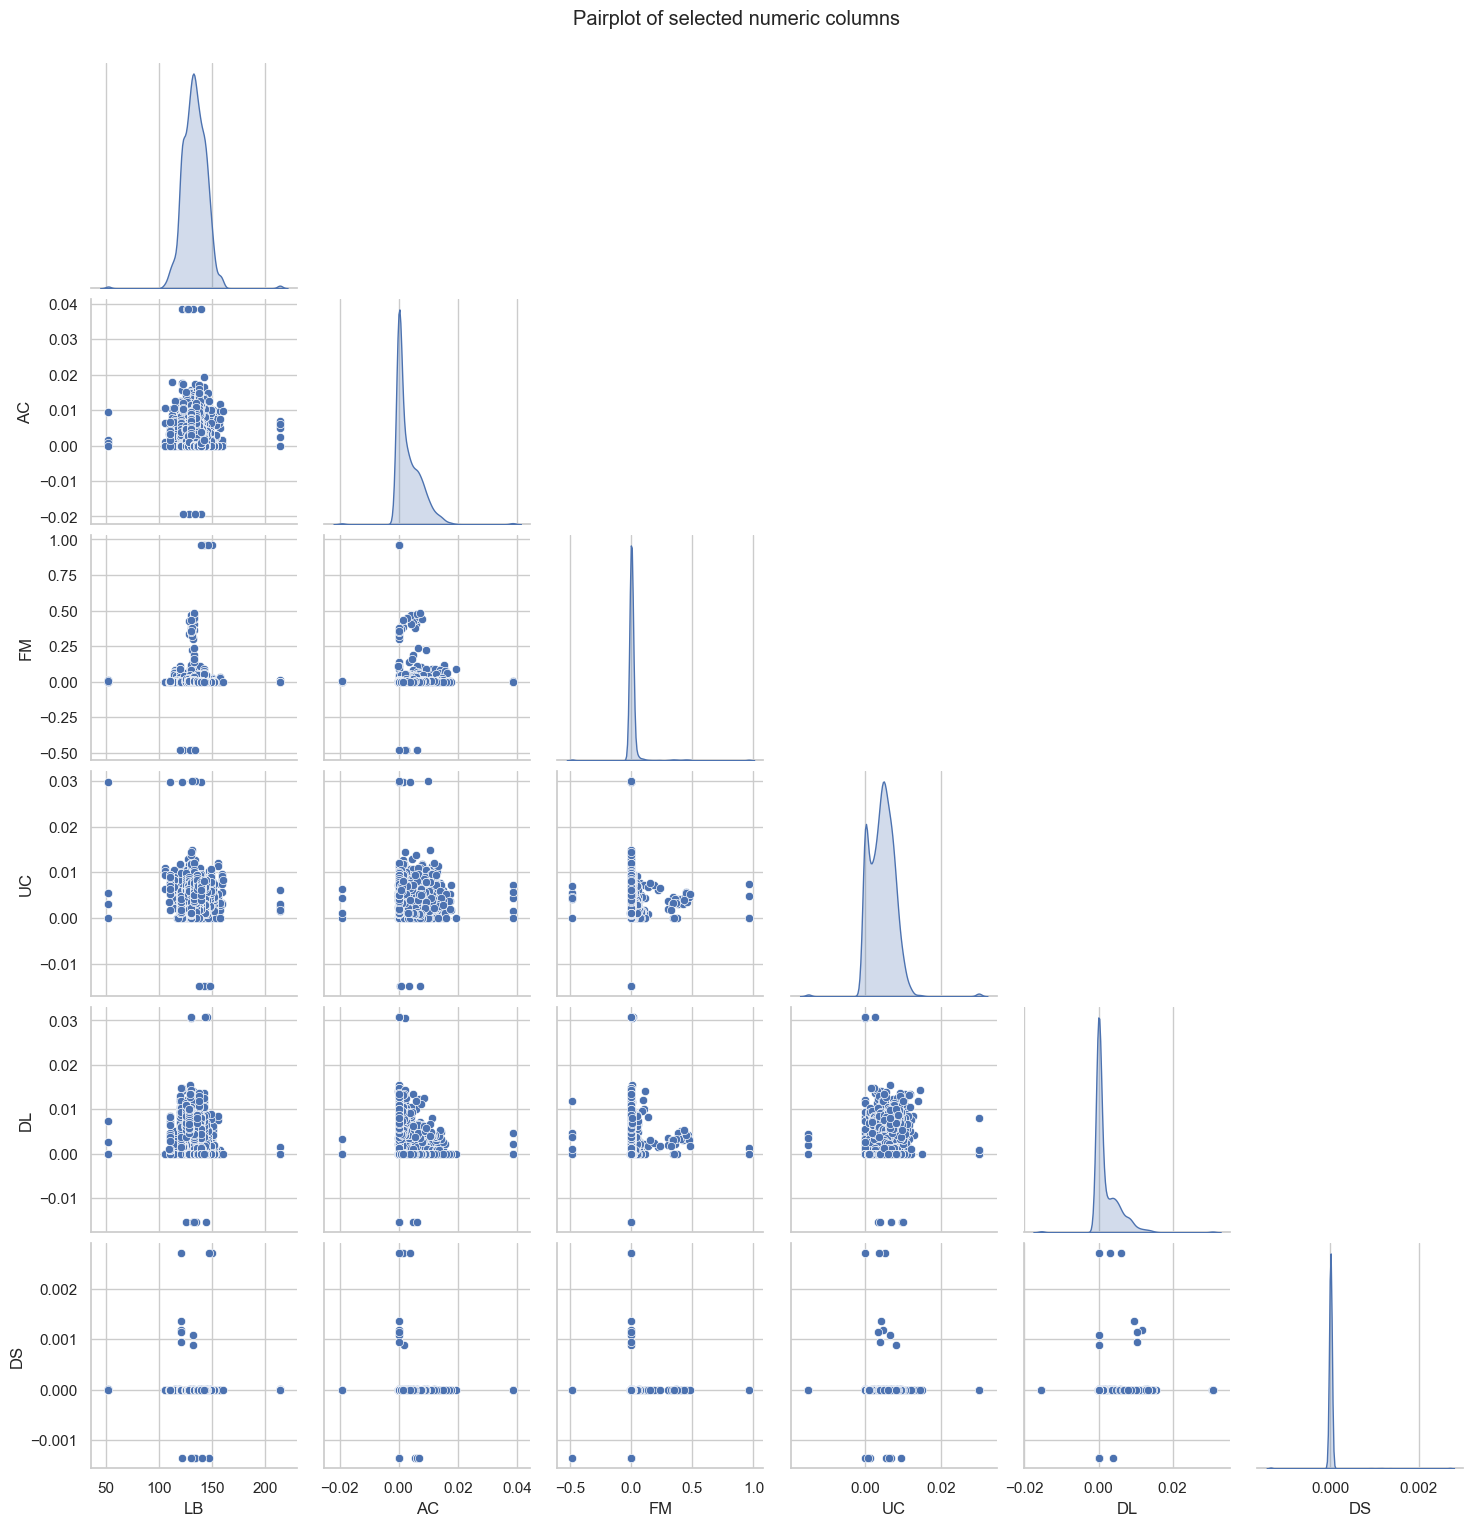

In [14]:
sel = num_cols[:6]  
sns.pairplot(df[sel].dropna(), diag_kind='kde', corner=True)
plt.suptitle("Pairplot of selected numeric columns", y=1.02)


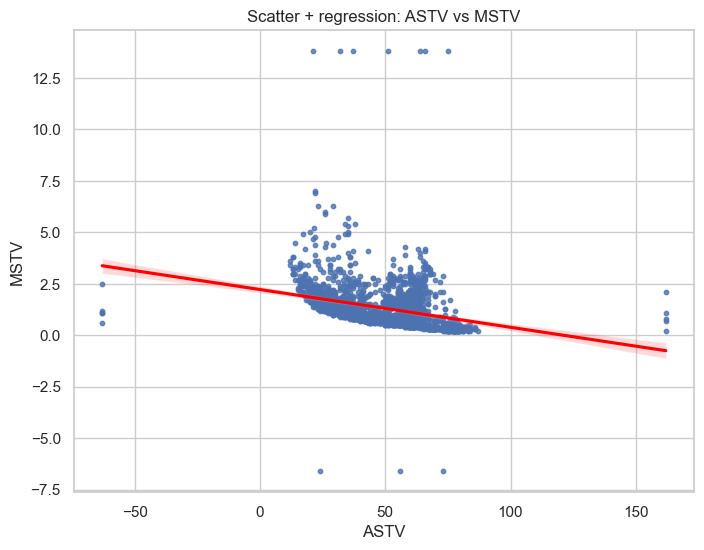

In [15]:
x_col = 'ASTV'  
y_col = 'MSTV' 
plt.figure(figsize=(8,6))
sns.regplot(data=df, x=x_col, y=y_col, scatter_kws={'s':10}, line_kws={'color':'red'})
plt.title(f"Scatter + regression: {x_col} vs {y_col}")
plt.show()


In [16]:
summary = pd.DataFrame(index=num_cols)
summary['mean'] = df[num_cols].mean()
summary['median'] = df[num_cols].median()
summary['std'] = df[num_cols].std()
summary['q1'] = df[num_cols].quantile(0.25)
summary['q3'] = df[num_cols].quantile(0.75)
summary['IQR'] = summary['q3'] - summary['q1']
summary = summary.round(3)
display(summary)


,mean,median,std,q1,q3,IQR
LB,133.342,133.000,11.268,126.000,140.000,14.000
AC,0.003,0.002,0.004,0.000,0.006,0.006
FM,0.010,0.000,0.068,0.000,0.003,0.003
UC,0.004,0.004,0.003,0.002,0.007,0.005
DL,0.002,0.000,0.003,0.000,0.003,0.003
DS,0.000,0.000,0.000,0.000,0.000,0.000
DP,0.000,0.000,0.001,0.000,0.000,0.000
ASTV,47.012,49.000,18.812,32.000,61.000,29.000
MSTV,1.364,1.200,1.174,0.700,1.700,1.000
ALTV,10.296,0.000,21.213,0.000,11.000,11.000


In [17]:
top_means = summary['mean'].sort_values(ascending=False).head(3)

skews = df[num_cols].skew().sort_values(ascending=False)
high_skew = skews[abs(skews) > 1]
top_means, high_skew


(LB       133.342
 Width     70.461
 ASTV      47.012
 Name: mean, dtype: float64,
 DS      8.414943
 FM      6.749691
 DP      6.419231
 MSTV    4.141709
 MLTV    3.543278
 ALTV    2.979526
 AC      2.016380
 DL      2.008927
 NSP     1.809369
 dtype: float64)

In [18]:
clean_path = 'D:\DS Assignment\EDA1\EDA1\Cardiotocographic_cleaned.csv'
df.to_csv(clean_path, index=False)
print("Saved cleaned data to", clean_path)


Saved cleaned data to D:\DS Assignment\EDA1\EDA1\Cardiotocographic_cleaned.csv


<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\SANSKAR\AppData\Local\Temp\ipykernel_2092\1721814764.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  clean_path = 'D:\DS Assignment\EDA1\EDA1\Cardiotocographic_cleaned.csv'


##  Final Report: Key Insights & Conclusion

### 🔍 Key Patterns Discovered
1. **Fetal Heart Rate (LB)** is stable around 133 bpm (normal range: 110-160), indicating generally healthy baseline.
2. **Variability Features (ASTV, MSTV, ALTV, MLTV)** show high dispersion → fetal heart rate variability is inconsistent across samples.
3. **Skewness Alert**: Features like `FM` (Fetal Movements), `ALTV`, and `DP` are highly right-skewed. This means:
   - Most recordings show *low or zero* fetal movements/decelerations.
   - Extreme values are rare but clinically significant (possible distress signals).

###  Skewness Impact on Analysis
- Highly skewed variables can bias mean-based models (e.g., linear regression).
- **Recommendation**: Use median/IQR for summaries; apply log-transform or use tree-based models (Random Forest, XGBoost) for prediction tasks.

###  Important Variables for Further Analysis
| Variable | Why Important? |
|----------|---------------|
| **LB** (Baseline FHR) | Primary indicator of fetal well-being |
| **ASTV** (% Abnormal Short-term Variability) | High values may indicate fetal stress |
| **Width** (FHR pattern width) | Reflects autonomic nervous system maturity |
| **NSP** (Target variable) | Diagnostic class (1=Normal, 2=Suspect, 3=Pathological) |

###  Overall Findings
✅ Dataset is clean, balanced, and suitable for classification modeling.  
✅ Outliers are not errors — they likely represent *high-risk cases* needing medical attention.  
✅ Strong skewness in movement/deceleration features suggests "normal" is the default state; deviations are meaningful.  

###  Recommendations for Next Steps
1. **Feature Engineering**: Create binary flags for "high variability" (e.g., ASTV > 75th percentile).
2. **Model Selection**: Start with tree-based models (handle skewness/outliers naturally).
3. **Clinical Validation**: Cross-check outlier predictions with expert obstetrician review.
4. **Deployment**: Build a risk-score dashboard for real-time fetal monitoring support.

>  **Bottom Line**: This EDA confirms the dataset's clinical relevance. The next phase should focus on building an interpretable classifier to assist in early detection of fetal distress.

### Interview Questions: 

Q: What is K in KNN and how does it affect model performance?

A: K is the number of nearest neighbors used to predict the class. Small K → low bias, high variance (overfit); large K → high bias, low variance (underfit). Choose K by CV.

Q: Why scale features for KNN?

A: KNN uses distances; features on larger scales dominate distances. Scaling (StandardScaler or MinMaxScaler) ensures fair weighting.

Q: Difference between Euclidean and Manhattan distance? When to use which?

A: Euclidean (L2) is straight-line distance good for continuous, isotropic feature spaces. Manhattan (L1) sums axis distances; can be better with high-dimensional or sparse data and sometimes more robust to outliers.

Q: How did you choose the final K and metric in this assignment?

A: GridSearchCV/validation_curve across K and p values; chose the K & p with highest mean CV accuracy and acceptable std; applied one-standard-error principle for stability.

Q: What are limitations of KNN?

A: Sensitive to feature scaling, high prediction cost (lazy learner), affected by irrelevant/noisy features and curse of dimensionality (distance loses meaning in high dimensions).

Q: How does KNN handle categorical features?

A: KNN requires numeric distances; encode categoricals (one-hot, ordinal) or use specialized distance metrics (Hamming). One-hot increases dimensionality so be careful.

Q: What is the computational complexity of KNN?

A: Training is cheap (store data), prediction is O(n_features * n_samples) per query (naïve). Use KD-tree / Ball-tree or approximate methods for speed on large datasets.

Q: What is the role of weights in KNN?

A: weights='uniform' treats all neighbors equally; weights='distance' gives closer neighbors more influence, helpful when closer points are more reliable.

Q: How do you evaluate imbalance with KNN?

A: Use metrics beyond accuracy (precision, recall, F1, AUROC), stratified CV, and possibly class weighting or resampling methods to handle imbalance.

Q: Explain the “one-standard-error” rule.

A: Choose the simplest model (e.g., larger K) whose CV mean score is within one standard error of the best mean score — balances performance and model simplicity.

Q: If Euclidean and Manhattan give same CV scores, which to prefer and why?

A: Prefer Euclidean for interpretability unless domain knowledge or lower variance suggests Manhattan; or prefer metric that gives better recall for target class as per project goals.

Q: How to make KNN robust to irrelevant features?

A: Feature selection/engineering (PCA, mutual information), use distance weighting, or reduce dimensionality (PCA) before KNN.